<a href="https://colab.research.google.com/github/priyanshukum-array/ML_PROJECTS/blob/main/Pneumonia_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mt
import seaborn as sns


In [2]:
pip install opendatasets

In [3]:
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia"

od.download(dataset_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: PriyanshuKumar1775
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:15<00:00, 160MB/s]


In [4]:
import tensorflow as tf

In [5]:
#to load data into tensor flow
import os

os.listdir("chest-xray-pneumonia")

['chest_xray']

In [6]:
#as train and test data is already split
train_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [7]:
#normalizing the image
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

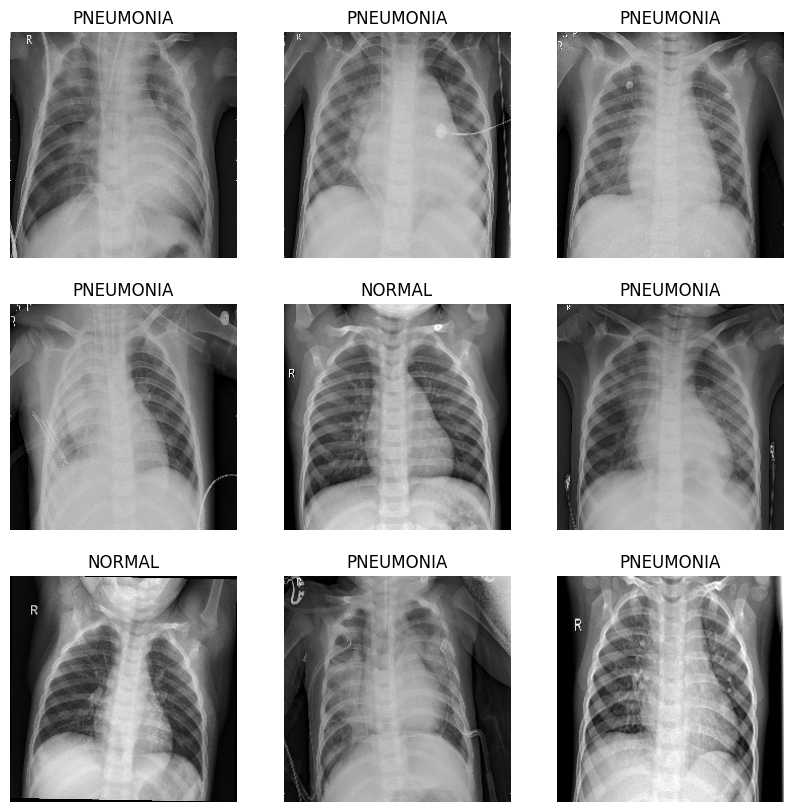

In [8]:
import matplotlib.pyplot as mt

mt.figure(figsize=(10,10))

# Define class_names as it was lost after the .map() operation
class_names = ['NORMAL', 'PNEUMONIA']

for images, labels in train_ds.take(1):
    for i in range(9):
        mt.subplot(3,3,i+1)
        mt.imshow(images[i].numpy(), cmap="gray")
        mt.title(class_names[labels[i]]) # Use the new class_names variable
        mt.axis("off")

In [9]:
#getting the pre trained model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [10]:
#loading the pre-trained mmodel
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
#freezing the cnn
#it does not change weight inside mobinet
base_model.trainable = False

In [12]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

In [13]:
#compiling
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
#taining
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 421ms/step - accuracy: 0.8847 - loss: 0.2837 - val_accuracy: 0.9684 - val_loss: 0.1036
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.9535 - loss: 0.1404 - val_accuracy: 0.9732 - val_loss: 0.0832
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 228ms/step - accuracy: 0.9607 - loss: 0.1149 - val_accuracy: 0.9837 - val_loss: 0.0577
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.9662 - loss: 0.1004 - val_accuracy: 0.9808 - val_loss: 0.0643
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 231ms/step - accuracy: 0.9720 - loss: 0.0889 - val_accuracy: 0.9684 - val_loss: 0.0842


In [15]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 724ms/step - accuracy: 0.8686 - loss: 0.3317
Accuracy: 0.8685897588729858
